In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision
from torchvision.datasets import CIFAR10

In [3]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = CIFAR10(root="./data_CIFAR10", train=True, download=False, transform=transform)
testset = CIFAR10(root="./data_CIFAR10", train=False, download=False, transform=transform)

C:\Users\ASUS\anaconda3\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
train_loader = DataLoader(trainset , shuffle=True , batch_size=64)
test_loader = DataLoader(testset , batch_size=64)

### CNN Architechture

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv_layer = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),                      #(32,32,32)
            nn.ReLU(),                                                    #     |
            nn.MaxPool2d(2,2),    # Kernel_size=2 , stride_val=2          #(16,16,32)    
                                                                          #     |
            nn.Conv2d(32,64,kernel_size=3,padding=1),                     #(16,16,64)
            nn.ReLU(),                                                    #     |
            nn.MaxPool2d(2,2),                                            # (8,8,64) 
                                                                          #     |
            nn.Conv2d(64,128,kernel_size=3,padding=1),                    # (8,8,128)
            nn.ReLU(),                                                    #     |
            nn.MaxPool2d(2,2)    # Kernel_size=2 , stride_val=2           # (4,4,128)
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(4*4*128 , 256),
            nn.ReLU(),

            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv_layer(x)
        x = x.view(x.size(0),-1)  # Flattening 
        x = self.fc_layer(x)

        return x

In [5]:
model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

### Training model

In [18]:
epochs = 20
train_loss = []
test_loss = []

for epoch in range (epochs):
    running_train_loss = 0.0
    running_test_loss = 0.0
    model.train()

    for images ,labels in train_loader:
        optimizer.zero_grad()
        
        output = model.forward(images)
        loss = criterion(output , labels)
        loss.backward()
        optimizer.step()  
        running_train_loss += loss.item()
        
    epoch_train_loss = running_train_loss/len(train_loader)
    train_loss.append(epoch_train_loss)
        
    model.eval()
    with torch.no_grad():
        for images , labels in test_loader:
            
            output = model.forward(images)
            loss = criterion(output , labels)
            running_test_loss = loss.item()

        epoch_test_loss = running_test_loss/len(test_loader)
        test_loss.append(epoch_test_loss)

    print(f"epoch = {epoch+1} & Training loss:{epoch_train_loss} & Testing loss: {epoch_test_loss}")

epoch = 1 & Training loss:0.11837417541710121 & Testing loss: 0.007041107317444625
epoch = 2 & Training loss:0.10506973615692705 & Testing loss: 0.0090942603008003
epoch = 3 & Training loss:0.09554349650453796 & Testing loss: 0.014492388743503839
epoch = 4 & Training loss:0.0869341204318044 & Testing loss: 0.012178486319863872
epoch = 5 & Training loss:0.07538357249412285 & Testing loss: 0.014312637839347693
epoch = 6 & Training loss:0.06853274350611926 & Testing loss: 0.010652943781227064
epoch = 7 & Training loss:0.07649468465576001 & Testing loss: 0.01606402579386523
epoch = 8 & Training loss:0.07177024019990459 & Testing loss: 0.016252608815575862
epoch = 9 & Training loss:0.060631505820168956 & Testing loss: 0.01154795194127757
epoch = 10 & Training loss:0.06221517220230611 & Testing loss: 0.012838205714134654
epoch = 11 & Training loss:0.06334611676160551 & Testing loss: 0.0116340263633971
epoch = 12 & Training loss:0.06130578323482367 & Testing loss: 0.010523798359427482
epoch =

In [19]:
# Evaluation for CNN
correct_labels = 0.0
total_labels = 0.0

model.eval
with torch.no_grad():
    for images , labels in test_loader:
        output = model.forward(images)
        _ , predicted = torch.max(output,1)

        correct_labels = (predicted == labels).sum().item()
        total_labels = labels.size(0)

print(f"accuracy value : {correct_labels/total_labels}")

accuracy value : 0.8125


In [20]:
loss_df = pd.DataFrame({
    "Training loss":train_loss,
    "Evaluation loss":test_loss
})

In [23]:
loss_df.head()

,Training loss,Evaluation loss
0,0.118374,0.007041
1,0.105070,0.009094
2,0.095543,0.014492
3,0.086934,0.012178
4,0.075384,0.014313


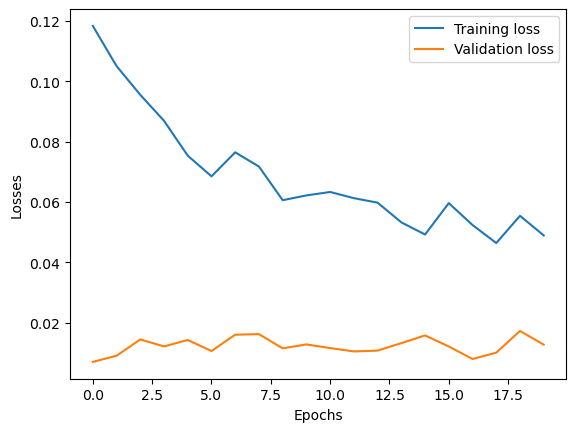

In [22]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(12,8))

plt.plot(loss_df["Training loss"] , label="Training loss")
plt.plot(loss_df["Evaluation loss"] , label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()